# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
# This notebook was executed in Google Colab.

# Kaleido is required to export Plotly charts as static images.
# By default, Plotly renders interactive JavaScript charts in Colab,
# but this JavaScript is not saved when the notebook is downloaded.
# Kaleido converts the chart to a PNG that gets permanently embedded
# in the notebook output — visible in VS Code or any other viewer.

!pip uninstall kaleido -y -q
!pip install kaleido==0.2.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.2 MB/s eta 0:00:00


In [1]:
from IPython.display import Image

In [2]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [3]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

In [4]:
df['year'].unique()

array([1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002,
       2007])

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


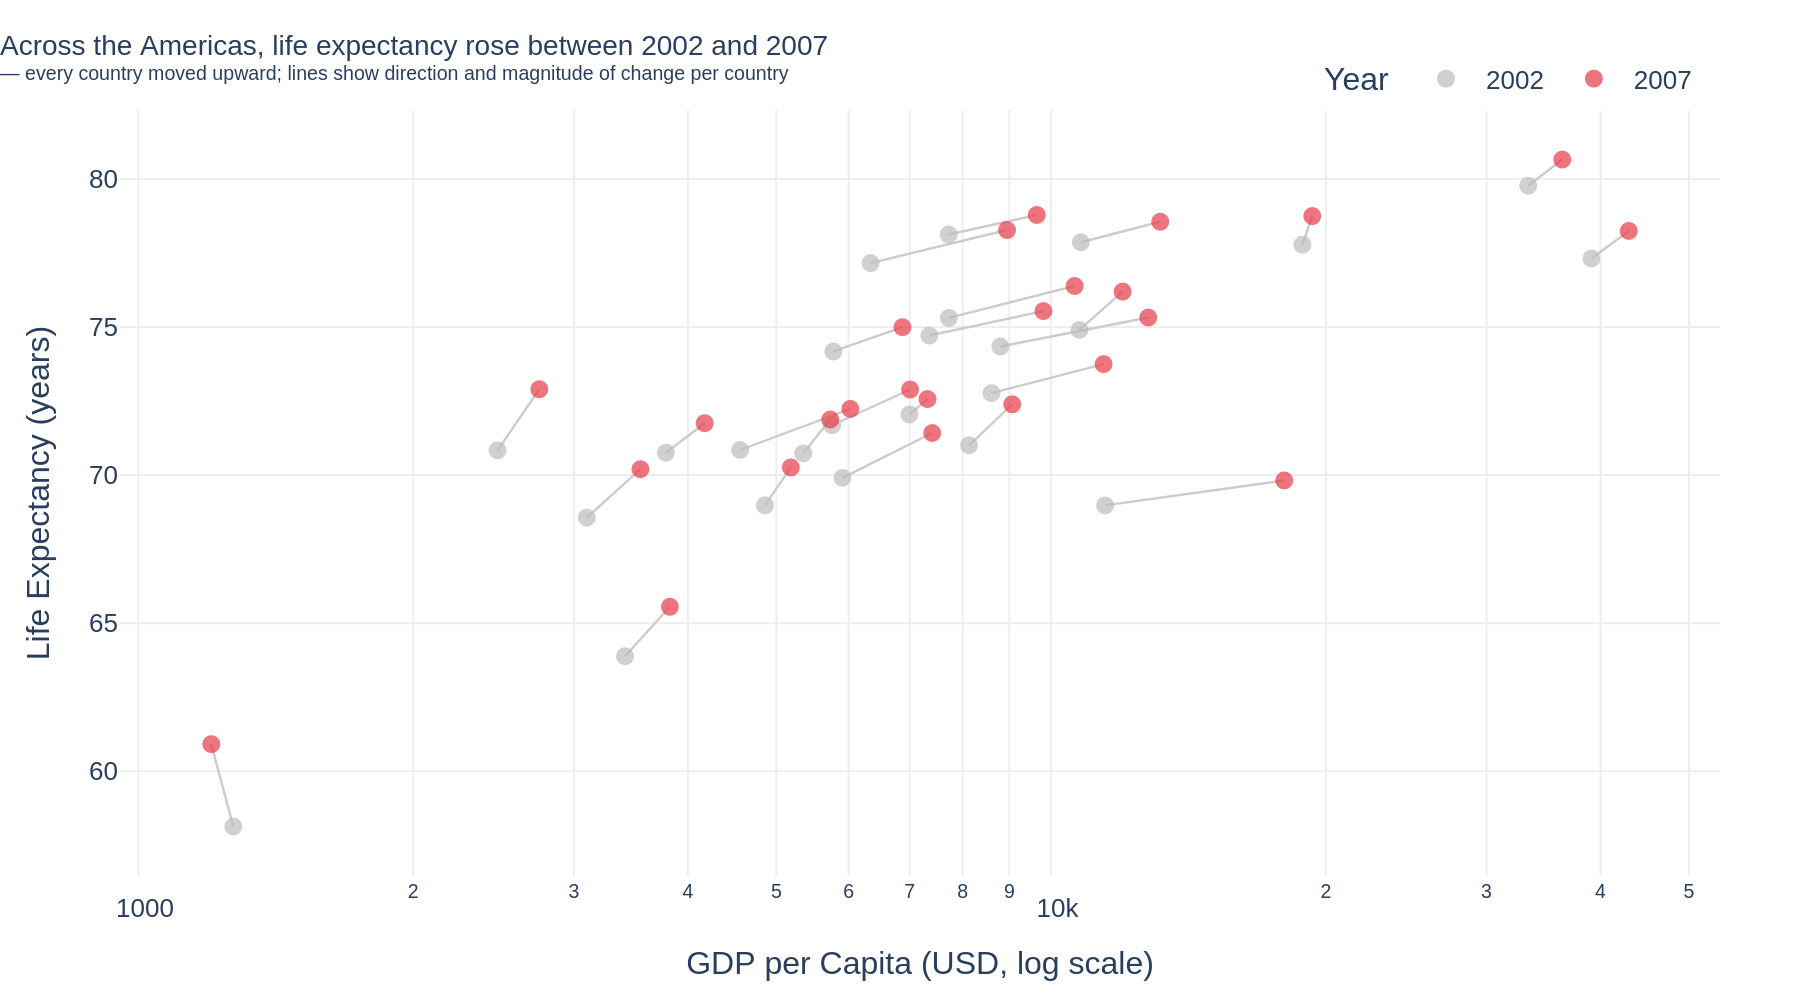

In [21]:
# Task 1
# YOUR CODE HERE

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = px.data.gapminder()

subset = df.loc[
    (df['continent'] == 'Americas') &
    (df['year'].isin([2002, 2007]))
].copy()
subset['year'] = subset['year'].astype(str)   # string → discrete colours, not gradient

df_2002 = subset[subset['year'] == '2002'].set_index('country')
df_2007 = subset[subset['year'] == '2007'].set_index('country')

fig = go.Figure()

for country in df_2002.index.intersection(df_2007.index):
    fig.add_trace(go.Scatter(
        x=[df_2002.loc[country, 'gdpPercap'], df_2007.loc[country, 'gdpPercap']],
        y=[df_2002.loc[country, 'lifeExp'],   df_2007.loc[country, 'lifeExp']],
        mode='lines',
        line=dict(color='#CCCCCC', width=1.2),
        showlegend=False,
        hoverinfo='skip'
    ))

fig.add_trace(go.Scatter(
    x=df_2002['gdpPercap'],
    y=df_2002['lifeExp'],
    mode='markers',
    name='2002',
    text=df_2002.index,
    hovertemplate='<b>%{text}</b><br>GDP: $%{x:,.0f}<br>Life Exp: %{y:.1f} yrs<extra></extra>',
    marker=dict(color='#BBBBBB', size=9, opacity=0.7)   # size=9, opacity=0.7 — matches notes
))

fig.add_trace(go.Scatter(
    x=df_2007['gdpPercap'],
    y=df_2007['lifeExp'],
    mode='markers',
    name='2007',
    text=df_2007.index,
    hovertemplate='<b>%{text}</b><br>GDP: $%{x:,.0f}<br>Life Exp: %{y:.1f} yrs<extra></extra>',
    marker=dict(color='#E63946', size=9, opacity=0.7)   # size=9, opacity=0.7 — matches notes
))

fig.update_layout(
      title=dict(
        text='Across the Americas, life expectancy rose between 2002 and 2007<br>'
             '<sup>— every country moved upward; lines show direction and magnitude of change per country</sup>',
        font=dict(size=14, family='Arial'),
        x=0, xanchor='left'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=13),
    xaxis=dict(
        type='log',
        showgrid=True,
        gridcolor='#EEEEEE',
        title='GDP per Capita (USD, log scale)'
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#EEEEEE',
        title='Life Expectancy (years)'
    ),

    margin=dict(l=60, r=40, t=55, b=40),
    height=500,
    legend=dict(
        title='Year',
        orientation='h',
        y=1.08, x=0.75
    )
)

fig.show()

fig.write_image("task_1.png", scale=2, width=900, height=500)
from IPython.display import Image
Image("task_1.png")

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


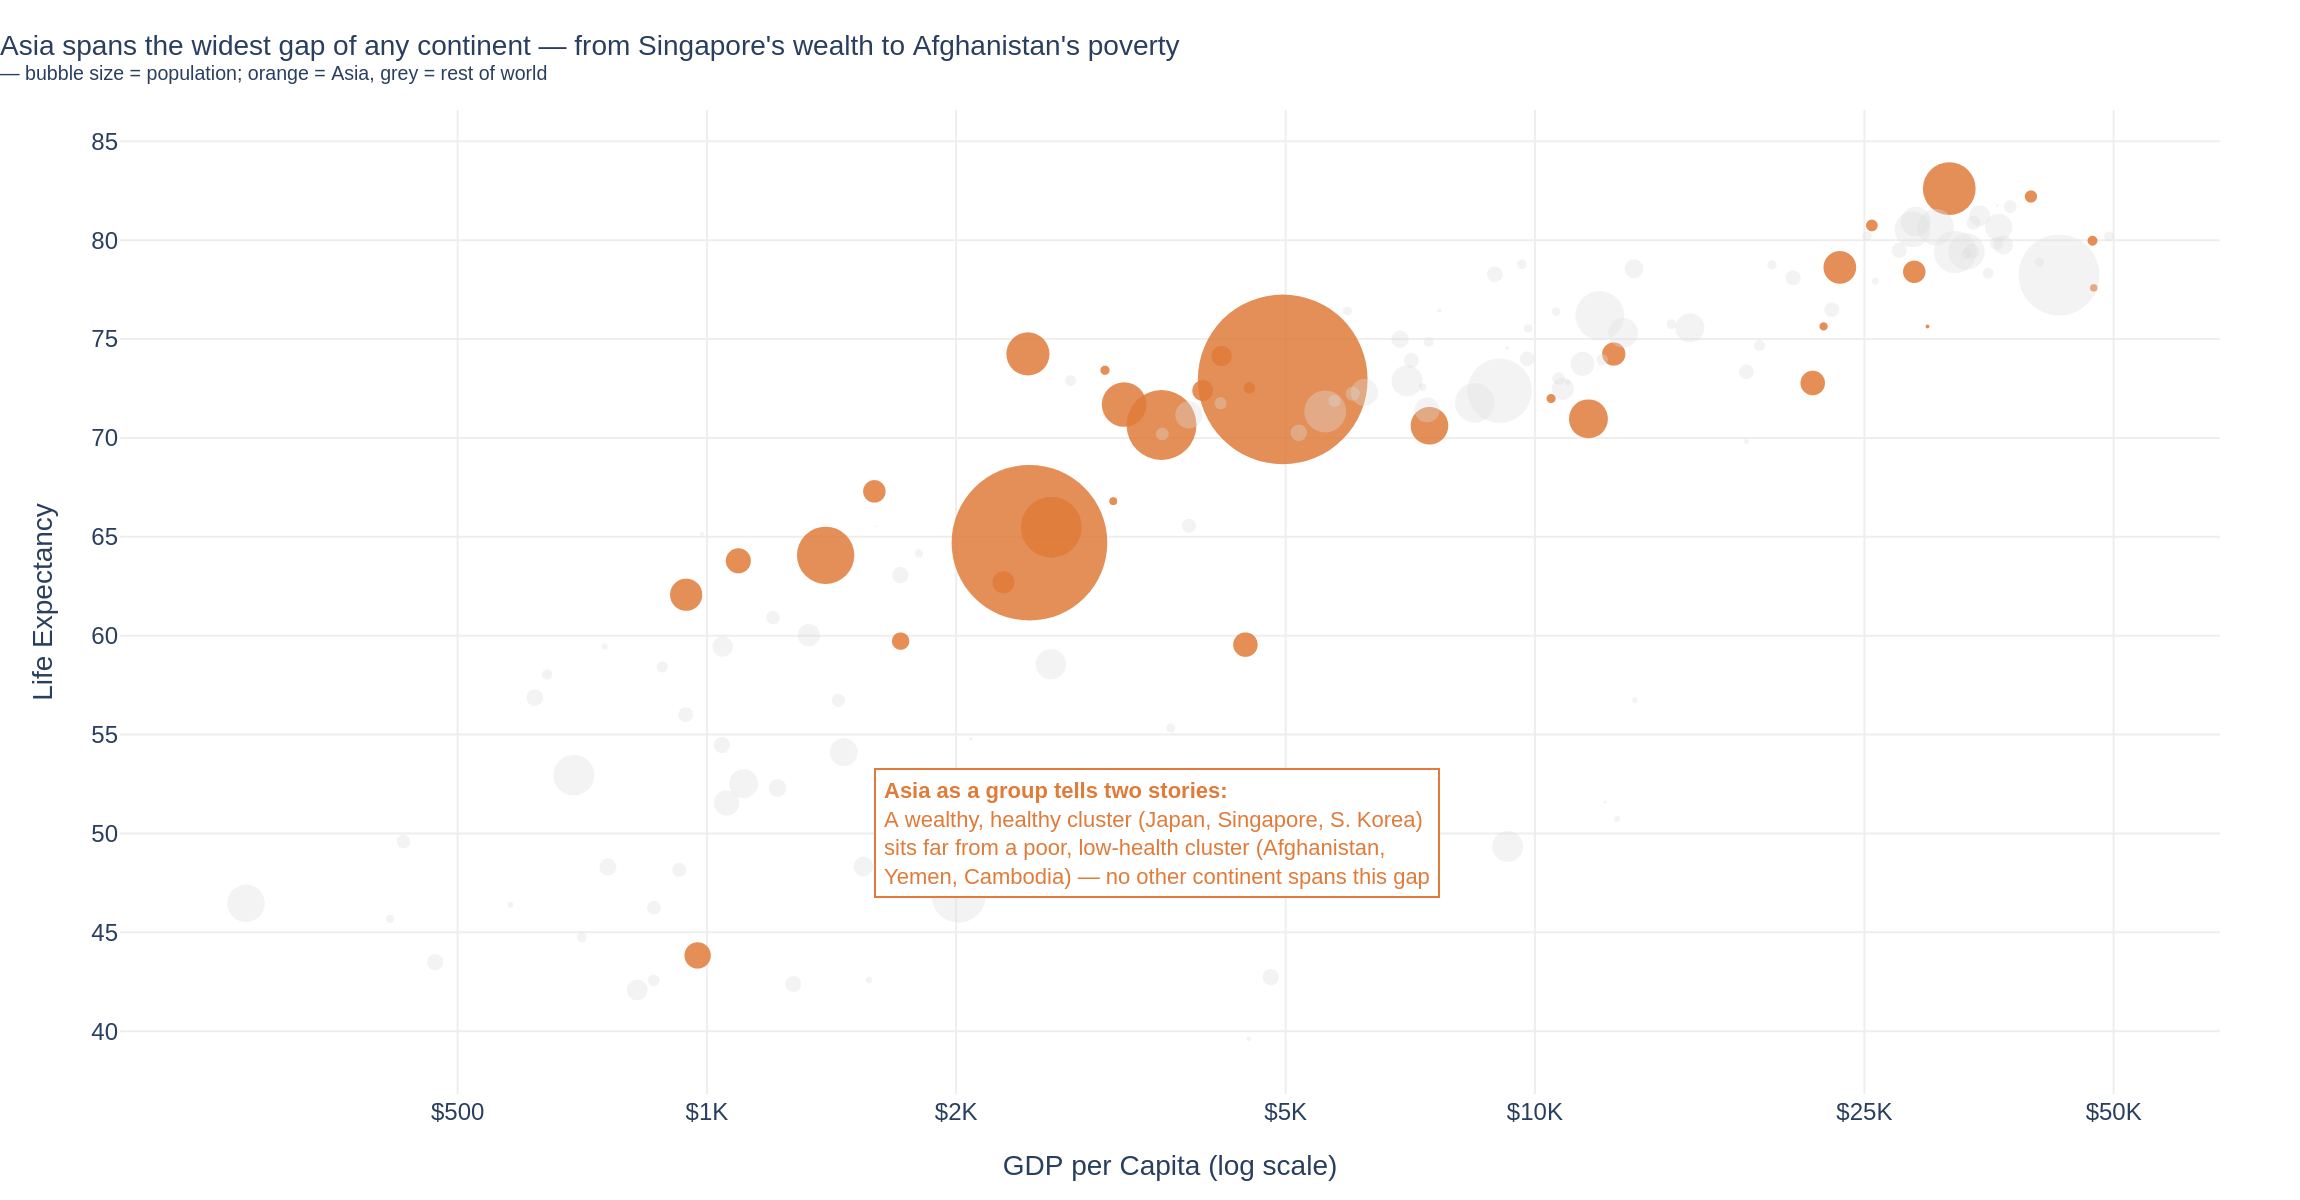

In [22]:
# Task 2
# YOUR CODE HERE

import pandas as pd
import plotly.express as px
import math

df_2007 = px.data.gapminder(year=2007)

highlight_continent = 'Asia'

colour_map = {
    c: ('#E07B39' if c == highlight_continent else '#DDDDDD')
    for c in df_2007['continent'].unique()
}

fig = px.scatter(
    data_frame=df_2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    color='continent',
    color_discrete_map=colour_map,
    hover_name='country',
    log_x=True,
    size_max=60,
    custom_data=['country', 'pop'],
    labels={
        'gdpPercap': 'GDP per Capita (log scale)',
        'lifeExp':   'Life Expectancy',
        'pop':       'Population',
        'continent': ''
    },
    height=600
)

fig.update_traces(
    hovertemplate='<b>%{hovertext}</b><br>'
                  'GDP per capita: $%{x:,.0f}<br>'
                  'Life expectancy: %{y:.1f} yrs<br>'
                  'Population: %{customdata[1]:,.0f}<extra></extra>'
)

fig.update_traces(showlegend=False)

fig.update_traces(
    selector=dict(name=highlight_continent),
    marker=dict(opacity=0.85, line=dict(width=0))
)
fig.update_traces(
    selector=lambda t: t.name != highlight_continent,
    marker=dict(opacity=0.35, line=dict(width=0))
)

fig.add_annotation(
    x=math.log10(3500), y=50,
    text=(
        '<b>Asia as a group tells two stories:</b><br>'
        'A wealthy, healthy cluster (Japan, Singapore, S. Korea)<br>'
        'sits far from a poor, low-health cluster (Afghanistan,<br>'
        'Yemen, Cambodia) — no other continent spans this gap'
    ),
    showarrow=False,
    font=dict(color='#E07B39', size=11, family='Arial'),
    bgcolor='white',
    bordercolor='#E07B39',
    borderwidth=1,
    borderpad=4,
    align='left'
)

for country, ax, ay in [
    ('Singapore',    60, -50),
    ('Afghanistan', -80,  30),
]:
    row = df_2007[df_2007['country'] == country].iloc[0]
    fig.add_annotation(
        x=row['gdpPercap'],
        y=row['lifeExp'],
        text=f'<b>{country}</b>',
        showarrow=True,
        arrowcolor='#E07B39',
        arrowhead=1,
        arrowwidth=1.5,
        ax=ax, ay=ay,
        font=dict(size=13, family='Arial', color='#E07B39'),
        bgcolor='rgba(255,255,255,0.8)'
    )

fig.update_layout(
    title=dict(
        text="Asia spans the widest gap of any continent — "
             "from Singapore's wealth to Afghanistan's poverty<br>"
             "<sup>— bubble size = population; orange = Asia, grey = rest of world</sup>",
        font=dict(size=14, family='Arial'),
        x=0, xanchor='left'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    yaxis=dict(gridcolor='#EEEEEE'),
    xaxis=dict(
        gridcolor='#EEEEEE',
        tickmode='array',
        tickvals=[500, 1000, 2000, 5000, 10000, 25000, 50000],
        ticktext=['$500', '$1K', '$2K', '$5K', '$10K', '$25K', '$50K'],
        tickangle=0
    ),
    margin=dict(l=60, r=40, t=55, b=40),
    height=600,
    width=1150,
    showlegend=False
)

fig.show()

fig.write_image("task_2.png", scale=2, width=1150, height=600)
Image("task_2.png")